# EDA: N-CMAPSS DS02

Goal: understand sensor channels, flight phases, health-state/RUL progression, and failure-mode distribution across units, as a basis for preprocessing decisions (cycle aggregation, feature selection, split).

Data source: `../data/N-CMAPSS_DS02.h5` (see `docs/data_download.md`).

In [1]:
import sys
sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import pandas as pd

from turbofan_rul.data import load_ncmapss_h5, list_units

DATA_PATH = "../data/N-CMAPSS_DS02.h5"

df_dev = load_ncmapss_h5(DATA_PATH, split="dev")
df_test = load_ncmapss_h5(DATA_PATH, split="test")
df_dev.shape, df_test.shape

((5263447, 47), (1253743, 47))

## Units and failure modes

In [2]:
print("Train units:", list_units(df_dev))
print("Test units:", list_units(df_test))
df_dev.groupby("a_unit")["a_cycle"].nunique()

Train units: [2.0, 5.0, 10.0, 16.0, 18.0, 20.0]
Test units: [11.0, 14.0, 15.0]


a_unit
2.0     75
5.0     89
10.0    82
16.0    63
18.0    71
20.0    66
Name: a_cycle, dtype: int64

## RUL distribution

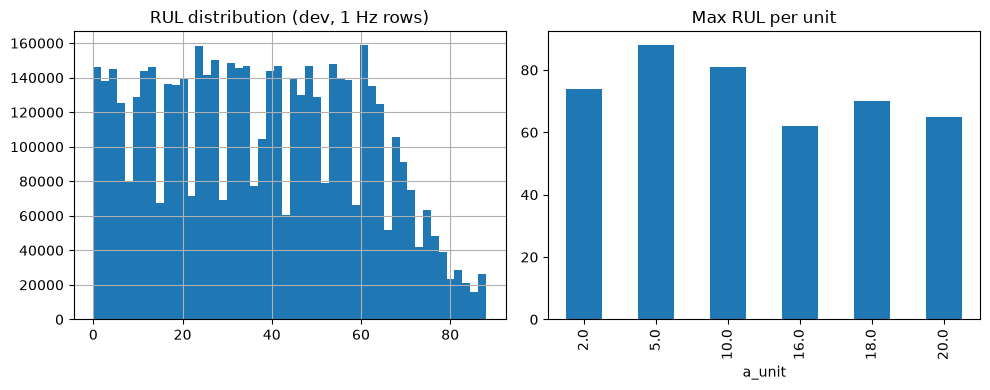

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
df_dev["rul"].hist(bins=50, ax=ax[0])
ax[0].set_title("RUL distribution (dev, 1 Hz rows)")
df_dev.groupby("a_unit")["rul"].max().plot(kind="bar", ax=ax[1])
ax[1].set_title("Max RUL per unit")
fig.tight_layout()

## Flight profile of a single unit (operating conditions over time)

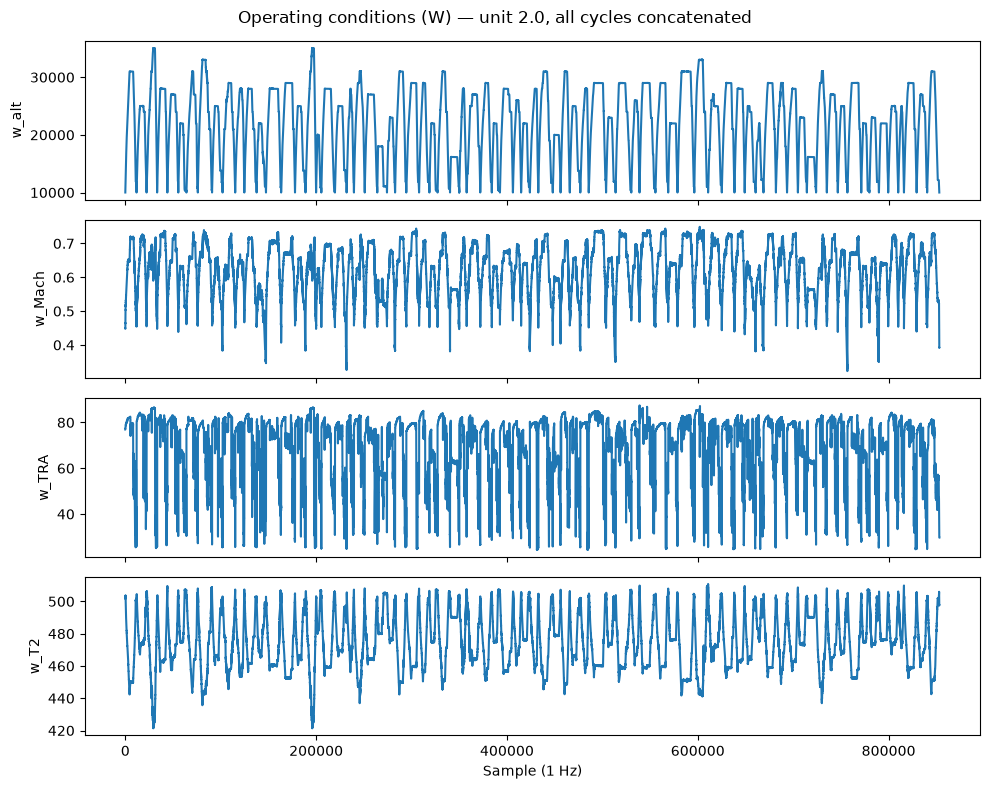

In [4]:
unit = list_units(df_dev)[0]
sample = df_dev[df_dev["a_unit"] == unit]
w_cols = [c for c in sample.columns if c.startswith("w_")]

fig, axes = plt.subplots(len(w_cols), 1, figsize=(10, 2 * len(w_cols)), sharex=True)
for ax, col in zip(axes, w_cols):
    ax.plot(sample[col].to_numpy())
    ax.set_ylabel(col)
axes[-1].set_xlabel("Sample (1 Hz)")
fig.suptitle(f"Operating conditions (W) — unit {unit}, all cycles concatenated")
fig.tight_layout()

## Sensor degradation across cycles (example channels)

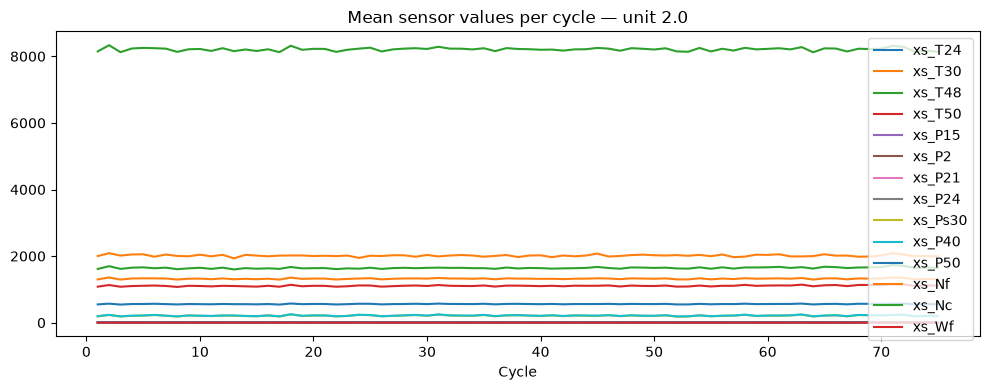

In [5]:
xs_cols = [c for c in sample.columns if c.startswith("xs_")]
per_cycle_mean = sample.groupby("a_cycle")[xs_cols].mean()

fig, ax = plt.subplots(figsize=(10, 4))
per_cycle_mean.plot(ax=ax, legend=True)
ax.set_title(f"Mean sensor values per cycle — unit {unit}")
ax.set_xlabel("Cycle")
fig.tight_layout()

## Health state / flight class distribution

In [6]:
df_dev[["a_unit", "a_Fc", "a_hs"]].drop_duplicates(subset=["a_unit"]).sort_values("a_unit")

,a_unit,a_Fc,a_hs
0,2.0,3.0,1.0
853142,5.0,3.0,1.0
1886562,10.0,3.0,1.0
2839273,16.0,3.0,1.0
3604568,18.0,3.0,1.0
4495287,20.0,3.0,1.0


## Open questions for the preprocessing decision

- How much does cycle length (number of 1 Hz samples) vary between cycles/units? Determines window size for Track B.
- Is mean/std per cycle sufficient as a cycle feature for Track A, or is flight-phase-specific aggregation needed (climb/cruise/descent separately)?
- What does the RUL progression look like at the start of life (constant vs. immediately declining) — relevant for health-state segmentation?